# 12 Pot table, free against governed on rev 2A

Notebook 09 section 11 left one question open. On board D the MG90's position table moved between
the free 2S session and the sessions under the current limit, by about 4.4 counts rms through mid
travel and 12 at raw 2672. Three things changed in between and the data could not separate them.
A stall moved the low stop, every later capture ran under the current limit, and the pot had a few
more days of running on it. The test it named was a free session again on the servo as it is now.
If its table matches the governed one, the limit is not the cause.

That session exists now, on rev 2A board #1. The same MG90 ran a governed session (limit 280) and,
about two hours later, a free one (limit 1100, above every climb). No seek or arrival stalled between
them, though two bench runs held the output against a stop (section 7). This notebook builds a table
from each session, the way notebook 09 does, and compares them against the noise floor of each.
Sections 8 to 11 then run the test that separates what moves the table. Two more free sessions ran
right after the first, back to back, with the output held against both stops before the last one.

It is a new notebook rather than another section of notebook 09 because notebook 09 is built around
board D. Its tracker, its tables and its section 11 checks all run on board D's datasets, and a
section about rev 2A would mean re-running all of it for two datasets it never reads.
Notebook 11 made the same call for the back-EMF.

If you only want the short version:

- **The limit is not the cause.** The two rev 2A tables sit 2.2 to 2.5 counts rms apart,
  four times the 0.5 to 0.7 that two halves of either session sit apart. The gap stays the same with
  every rung's climb cut out, where both rules drive the motor the same way.
- **Loading at a stop is not the cause either, at the loads tried.** Across holds of 135 and 194 mA at
  both stops and a stalled ladder at the high stop, the table stepped 0.69 counts rms from one capture
  to the next. Next captures inside a session step 0.72 to 1.14. The stretch next to the high stop
  moved the least.
- **Running moves the table, slowly.** Through three hours of free sessions it drifts at the pace the
  captures run, the same across a bare 16 minute pause as across the stop holds. Captures an hour and
  a half or more apart sit about 1.65 counts rms apart. Temperature was not measured and stays open.
- **The governed to free move is a step, and still unexplained.** Every capture of each session sits
  2.1 to 2.4 counts from the other session's table, and forward and reverse rungs see the same change.
  At 2.5 counts rms it is bigger than three hours of free running moved the table (1.5), and its shape
  matches neither step of the free sessions. The output gear turned out to sit on the pot shaft through
  a friction bush, which makes a slip at a stop a candidate, but no constant raw shift of one table
  brings it under four times the floor (section 12), so a slip is not confirmed.
- **It is smaller than board D's and has a different shape.** Board D's move was 4.6 counts rms with
  narrow spots at raw 1264 and 2672. The rev 2A move is half that, a broad part and a narrow part about
  equal, and its largest spots sit at raw 960 and 1552. At 1264 and 2672 it moved under 3 counts.
- **What it costs.** Through the other session's table a held-out rung reads 3.1 to 3.2 counts rms
  against 2.3 through its own, so the move is 0.8 counts of position error. Board D's servo table on
  these captures reads 4.6 to 5.2.

## Picking a rig

Four datasets, the same servo in all of them. The two rev 2A sessions are the ones under test. Board
D's free session and its governed session come along so the same method can score board D's move and
the tables across boards.

In [1]:
import itertools
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import governed, poslut, ripple, session

ds = oscnb.use("mg90-a__dev-v006-2A__2s__limit")
board, servo = oscnb.current().board, oscnb.current().servo
SETS = {"2A governed": ds,
        "2A free": oscnb.datasets.load("mg90-a__dev-v006-2A__2s__limit-1100"),
        "D free": oscnb.datasets.load("mg90-a__2s"),
        "D governed": oscnb.datasets.load("mg90-a__2s__limit")}
Q15 = 32767
RAW = (0, (1 << poslut.ADC_BITS) - 1)       # stitch axis, the whole ADC domain


def complete(d):
    return [c for c in d.captures("session") if "slow" in {r.name for r in d.recordings("session", c)}]


def slow_meta(d, c):
    return [r for r in d.recordings("session", c) if r.name == "slow"][0].meta


rows = []
for label, d in SETS.items():
    ms = [slow_meta(d, c) for c in complete(d)]
    rails = [d.board.rail_from_vbus_counts(m["vbus_counts"]) for m in ms]
    rows.append({"set": label, "dataset": d.key, "board": d.board.key, "captured": d.decl["captured"],
                 "rule": d.rule, "current limit [counts]": d.decl.get("current_limit_counts"),
                 "captures": len(ms), "rail [V]": f"{min(rails):.2f} .. {max(rails):.2f}",
                 "table the servo ran": ", ".join(sorted({f"{m['plant']['lut_state']} {m['plant']['lut_crc']}"
                                                          for m in ms if "plant" in m})) or "-"})
pd.DataFrame(rows).set_index("set")

dataset  mg90-a__dev-v006-2A__2s__limit
supply   2s
rig      Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1



,captures,recordings per capture,names
experiment,,,
session,5,2,"fast, slow"



derived constants (what the hardware is)


value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from                               % duty                  5.3333
                 voltage settled from                               % duty                  7.7500
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800


measured values (what someone found when they looked)


value  \
where quantity                           
board rest_current_noise      1.280000   
      crest_floor             7.000000   
      shunt_settle          156.000000   
      current_chain_scale     0.500000   
servo gear_ratio            308.053333   
      ripple_order            6.000000   
      r_winding               4.890000   
      ke_ripple               1.295000   
      pot_scale              19.760000   
      travel                184.220000   
      low_stop_after_stall  232.000000   
      backlash                1.480000   

                                                                        unit  \
where quantity                                                                 
board rest_current_noise                                          counts RMS   
      crest_floor                                               % duty on 2S   
      shunt_settle          ticks from the ON compare to 1% of the 100% rung   
      current_chain_scale                                 % high vs Rs1 pads   
servo gear_ratio                                                          :1   
      ripple_order                                             per motor rev   
      r_winding                                                          Ohm   
      ke_ripple                                             mV per ripple Hz   
      pot_scale                                                   counts/deg   
      travel                                                             deg   
      low_stop_after_stall                                            counts   
      backlash                                                 ripple cycles   

                                       bracket  \
where quantity                                   
board rest_current_noise          [1.22, 1.33]   
      crest_floor                      [7, 10]   
      shunt_settle                  [150, 156]   
      current_chain_scale          [-0.7, 2.3]   
servo gear_ratio            [308.053, 308.053]   
      ripple_order                      [6, 6]   
      r_winding                   [4.49, 4.98]   
      ke_ripple                 [1.284, 1.306]   
      pot_scale                  [19.7, 19.85]   
      travel                  [178.67, 189.18]   
      low_stop_after_stall          [232, 236]   
      backlash                     [1.25, 1.5]   

                                                                       source  \
where quantity                                                                  
board rest_current_noise            nb10 sec 3, grid 2S ladder rest baselines   
      crest_floor               nb10 sec 5 and 8, static-load ladder + bursts   
      shunt_settle          nb10 sec 8, 2S grid bursts folded at 4 ticks, ...   
      current_chain_scale            Rs1 pads mV during a 4.2 s 100% grid lap   
servo gear_ratio                              mechanical/mg90/measurements.py   
      ripple_order                             teardown, 3-slot brushed motor   
      r_winding             bringup captures/mg90/plant.py, onset regressi...   
      ke_ripple             nb09 sec 3, settled windows of the 15-50% grid...   
      pot_scale             nb09 sec 10, ripple cycles stitched over the c...   
      travel                nb09 sec 10, phys stop to phys stop 209..3849:...   
      low_stop_after_stall  hand stop, firm push, 2026-09-28, after the st...   
      backlash              nb09 sec 4, reversal blocks, commutation steps...   

                                                                       caveat  
where quantity                                                                 
board rest_current_noise    the whole chain at rest with the bridge off, o...  
      crest_floor           honest to 3% from 7%, and the 7% edge is tap A...  
      shunt_settle          3.25 us, in high-speed mode. The current close...  
      current_chain_scale   meter 93-94 mV across Rs1 against 93.3-95.1 mV...  
servo g

,dataset,board,captured,rule,current limit [counts],captures,rail [V],table the servo ran
set,,,,,,,,
2A governed,mg90-a__dev-v006-2A__2s__limit,dev-v006-2A,2026-10-02,limit,280.0,5,7.45 .. 7.48,IDENTITY 0x0000
2A free,mg90-a__dev-v006-2A__2s__limit-1100,dev-v006-2A,2026-10-02,limit,1100.0,5,7.36 .. 7.41,LIVE 0xdc96
D free,mg90-a__2s,dev-v006-D,2026-09-26,free,NaN,5,7.80 .. 7.92,-
D governed,mg90-a__2s__limit,dev-v006-D,2026-09-30,limit,280.0,5,7.79 .. 7.87,LIVE 0x14fb


**What you are looking at.** One row per dataset. The rail is read at the start of each capture.

The free session ran the 0xdc96 table live, the one `osc lut build` made from the governed session.
That does not touch anything here. TEL `pos` is the raw count in every recording, and the session
drives open loop, so the table only ever moved a seek goal. The rail sits 0.1 V lower on the free
session, which the pot does not see. It reads its wiper against the same 3V3 the ADC does.

## 1. The tables

Each grid rung goes through the ripple tracker the way notebook 09 runs it. The motor angle comes from
counting commutation ripple, the pot only seeds the tracker's search band. A rung counts when the
tracker holds the line over 90% of it and its coupling, ripple cycles per pot count, sits within 3%
of its set's median. The frequency floor is 200 Hz on rev 2A, as in notebook 11, and notebook 09's
250 on board D.

A table is the stitch of every accepted rung's pot samples against its motor angle, from the first
tracked sample to the end of the rung, put on the firmware's 16-count grid. The governed session's grid
stops at 30%, so both rev 2A tables use the 15 to 30% rungs. Board D's use notebook 09's 15 to 50%.

In [2]:
def frames(d):
    for c in complete(d):
        df, meta = session.read(d, c, "grid")
        yield c, df, meta


def coupling_prior(d):
    out = []
    for cap, df, meta in frames(d):
        bias = df[df.seg == 0].current_raw.mean()
        for seg, g in df[df.seg > 0].groupby("seg"):
            if not 20 <= abs(g.cmd_duty_q15.iloc[0] * 100 / Q15) <= 30:
                continue
            st = governed.settled(g, d.board.tick_hz)
            f, X = ripple.line_spectrum(st.current_raw.to_numpy() - bias, d.board.tick_hz)
            out.append(ripple.settled_line(f, X)[0] / abs(ripple.pot_speed(st, d.board.tick_hz, 1.0)))
    return float(np.median(out))


def track(d, label, f_floor):
    fs = d.board.tick_hz
    cp = coupling_prior(d)
    out = []
    for cap, df, meta in frames(d):
        df = df.assign(bias=df[df.seg == 0].current_raw.mean())
        for seg, g in df[df.seg > 0].groupby("seg"):
            duty = int(round(g.cmd_duty_q15.iloc[0] * 100 / Q15))
            if abs(duty) < 12 or g.cmd_duty_q15.nunique() > 1:
                continue
            k = governed.goal_from(g)
            r = {"set": label, "cap": cap, "duty": duty, "n": len(g), "pos": g.pos.to_numpy(),
                 "s0": governed.settled_from(g, fs), "goal_ms": np.nan if k is None else k * 1e3 / fs}
            cyc, n0, _ = ripple.motor_angle(g, cp, fs, 1.0, f_floor=f_floor)
            if cyc is None or r["s0"] is None:
                out.append(dict(r, ok=False))
                continue
            p = r["pos"]
            r.update(cyc=cyc, n0=n0, accept=(len(g) - n0) / len(g),
                     cpc=(cyc[-1] - cyc[n0]) / abs(p[-1] - p[n0]) if p[-1] != p[n0] else np.nan)
            out.append(r)
    med = np.median([r["cpc"] for r in out if "cyc" in r and 15 <= abs(r["duty"]) <= 50])
    for r in out:
        r["ok"] = "cyc" in r and r["accept"] >= 0.90 and abs(r["cpc"] / med - 1) < 0.03
    return out


RUNGS = {label: track(d, label, 200.0 if d.board.key == board.key else 250.0) for label, d in SETS.items()}
G, F, DF, DG = (RUNGS[k] for k in SETS)


def sel(lo, hi, sign=0):
    return lambda r: r["ok"] and lo <= abs(r["duty"]) <= hi and (sign == 0 or np.sign(r["duty"]) == sign)


LO30, ALL50 = sel(15, 30), sel(15, 50)
CORE = {"2A governed": LO30, "2A free": LO30, "D free": ALL50, "D governed": ALL50}
FROM_N0 = lambda r: r["n0"]
SETTLED = lambda r: max(r["n0"], r["s0"])


def chunks(rs, pick, start=FROM_N0):
    return [(r["pos"][start(r):], r["cyc"][start(r):]) for r in rs if pick(r)]


def stitch(rs, pick, start=FROM_N0):
    return poslut.stitch(chunks(rs, pick, start), *RAW)


rows = []
for label, rs in RUNGS.items():
    t = pd.DataFrame([{k: r.get(k) for k in ("duty", "ok", "cpc", "goal_ms")} for r in rs])
    t = t[t.duty.abs() <= 50]
    st = stitch(rs, CORE[label])
    rows.append({"set": label, "rungs 15-50%": len(t), "accepted": int(t.ok.sum()),
                 "in the table": sum(CORE[label](r) for r in rs),
                 "cycles per count, median": t[t.ok].cpc.median(),
                 "climb to the goal at 30% [ms]": t[t.duty.abs() == 30].goal_ms.median(),
                 ">= 20 rungs cross": poslut.well_covered(st)})
pd.DataFrame(rows).set_index("set").round(4)

,rungs 15-50%,accepted,in the table,"cycles per count, median",climb to the goal at 30% [ms],>= 20 rungs cross
set,,,,,,
2A governed,40,40,40,0.2709,29.175,"(676, 3438)"
2A free,80,77,39,0.2698,3.525,"(811, 3184)"
D free,80,79,79,0.2622,0.050,"(544, 3520)"
D governed,70,70,70,0.2673,21.200,"(578, 3486)"


**What you are looking at.** One row per set. The rungs from 15 to 50% the grid holds, how many the
tracker accepted, how many go into the table, the coupling over each whole rung, how long a 30% rung
takes to reach its duty, and the stretch at least 20 of the table's rungs cross.

Every governed rung and all but three free ones track. The couplings differ by 0.4% between the two
rev 2A sessions, the same size as the gap between the tracker's seed priors. That is a scale, and every comparison below removes offset and slope before it measures anything. The climb is
the difference between the rules. A 30% rung takes 29 ms to reach its duty under the 280 limit and 3.5
ms under 1100.

The free 15 to 30% table has the narrowest well covered stretch, 811 to 3184, so every rev 2A table
below is anchored on that one band. Anchoring all of them on one band keeps a table built from fewer
rungs from bending at a band edge of its own. Inside the band nothing depends on the anchor beyond an
offset and a slope.

In [3]:
BAND = poslut.well_covered(stitch(F, LO30))
X = np.arange(BAND[0], BAND[1] + 1)


def table(rs, pick, start=FROM_N0, band=BAND):
    s = stitch(rs, pick, start)
    assert s.lo <= band[0] and s.hi >= band[1], (s.lo, s.hi, band)
    return poslut.fit_grid(s, band=band)


def apart(t1, t2, x=X):
    # the difference of two tables in linearized counts, offset and slope removed
    d = t1.counts(x) - t2.counts(x)
    return d - np.polyval(np.polyfit(x, d, 1), x)


def caps(rs, which):
    return [r for r in rs if r["cap"] in which]


ODD, EVEN = ("capture-1", "capture-3", "capture-5"), ("capture-2", "capture-4")
T = {"2A governed": table(G, LO30), "2A free": table(F, LO30)}
T_built = {k: poslut.GridLut.from_json((SETS[k].path / "pos-lut-built.json").read_text()) for k in T}

for k in T:
    d = apart(T[k], T_built[k])
    print(f"{k}: the table here against osc lut build's pos-lut-built.json, {d.std():.2f} counts rms, "
          f"{np.abs(d).max():.2f} at worst")
d = T_built["2A free"].counts(X) - T_built["2A governed"].counts(X)
print(f"osc's two tables, free against governed over {BAND[0]} .. {BAND[1]}: {np.sqrt(np.mean(d ** 2)):.2f} counts rms "
      f"as they stand, {apart(T_built['2A free'], T_built['2A governed']).std():.2f} with offset and slope removed")

2A governed: the table here against osc lut build's pos-lut-built.json, 0.39 counts rms, 1.16 at worst
2A free: the table here against osc lut build's pos-lut-built.json, 0.58 counts rms, 2.05 at worst
osc's two tables, free against governed over 811 .. 3184: 8.66 counts rms as they stand, 2.48 with offset and slope removed


The tables built here and the ones `osc lut build` wrote agree to 0.4 and 0.6 counts rms, so the
Python port and the tool see the same pot. The tool anchors each table on its own well covered stretch,
and the two stretches differ, 679 to 3437 against 482 to 3596. So osc's two tables differ by 8.7 counts
rms as they stand and only 2.5 once offset and slope come out. The 8.7 is the anchoring and the scale,
not the pot, and the same goes for the 9.85 counts of raw point difference in the bench notes.

## 2. How far apart, against the noise floor

The noise floor is how far apart two tables built from the same session sit. Captures 1, 3 and 5 make
one, 2 and 4 the other. A duty split checks that speed does not move a table inside a session. The
settled rows answer the limit question directly. They cut each rung down to its settled part, which
starts 40 ms after the applied duty reaches the goal. From there on both rules drive the motor the same
way, so a gap that survives the cut is not the climb. The settled parts cover less travel, so those rows
use the stretch at least 10 settled rungs of both sessions cross.

whole rungs over 811 .. 3184


,rms [counts],largest [counts],at raw
pair,,,
free against governed,2.52,6.77,960
free (15-50%) against governed,2.46,6.80,1552
"governed, captures 1, 3, 5 against 2, 4",0.67,1.80,880
"free, captures 1, 3, 5 against 2, 4",0.57,1.72,2704
"governed, 15-20% against 25-30%",1.24,5.28,2704
"free, 15-20% against 25-30%",0.65,-1.65,2496
"free, 15-25% against 35-50%",0.90,3.80,976


settled parts over 1298 .. 2807


,rms [counts],largest [counts],at raw
pair,,,
"free against governed, whole rungs",2.29,5.99,1568
"free against governed, settled parts",2.45,7.87,1568
"governed halves, settled parts",0.58,2.28,1312
"free halves, settled parts",0.57,1.59,2704


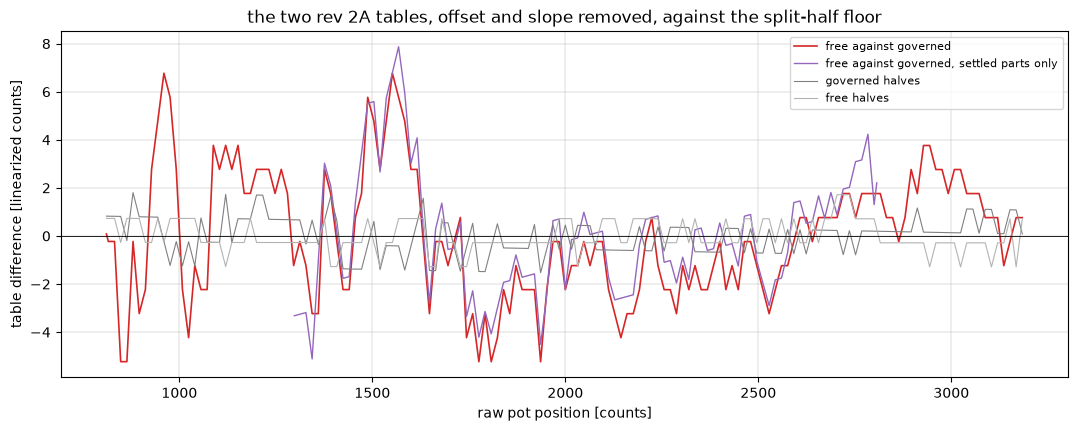

In [4]:
cov = [poslut.well_covered(stitch(rs, LO30, SETTLED), 10) for rs in (G, F)]
SB = (max(c[0] for c in cov), min(c[1] for c in cov))
XS = np.arange(SB[0], SB[1] + 1)


def summary(name, d, x):
    k = np.abs(d).argmax()
    return {"pair": name, "rms [counts]": d.std(), "largest [counts]": d[k], "at raw": x[k]}


gaps = {
    "free against governed": apart(T["2A free"], T["2A governed"]),
    "free (15-50%) against governed": apart(table(F, sel(15, 50)), T["2A governed"]),
    "governed, captures 1, 3, 5 against 2, 4": apart(table(caps(G, ODD), LO30), table(caps(G, EVEN), LO30)),
    "free, captures 1, 3, 5 against 2, 4": apart(table(caps(F, ODD), LO30), table(caps(F, EVEN), LO30)),
    "governed, 15-20% against 25-30%": apart(table(G, sel(15, 20)), table(G, sel(25, 30))),
    "free, 15-20% against 25-30%": apart(table(F, sel(15, 20)), table(F, sel(25, 30))),
    "free, 15-25% against 35-50%": apart(table(F, sel(15, 25)), table(F, sel(35, 50))),
}
settled_gaps = {
    "free against governed, whole rungs": apart(table(F, LO30, band=SB), table(G, LO30, band=SB), XS),
    "free against governed, settled parts": apart(table(F, LO30, SETTLED, SB), table(G, LO30, SETTLED, SB), XS),
    "governed halves, settled parts": apart(table(caps(G, ODD), LO30, SETTLED, SB), table(caps(G, EVEN), LO30, SETTLED, SB), XS),
    "free halves, settled parts": apart(table(caps(F, ODD), LO30, SETTLED, SB), table(caps(F, EVEN), LO30, SETTLED, SB), XS),
}
print(f"whole rungs over {BAND[0]} .. {BAND[1]}")
display(pd.DataFrame([summary(k, v, X) for k, v in gaps.items()]).set_index("pair").round(2))
print(f"settled parts over {SB[0]} .. {SB[1]}")
display(pd.DataFrame([summary(k, v, XS) for k, v in settled_gaps.items()]).set_index("pair").round(2))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(X, gaps["free against governed"], lw=1.2, color="tab:red", label="free against governed")
ax.plot(XS, settled_gaps["free against governed, settled parts"], lw=1.0, color="tab:purple",
        label="free against governed, settled parts only")
ax.plot(X, gaps["governed, captures 1, 3, 5 against 2, 4"], lw=0.8, color="0.5", label="governed halves")
ax.plot(X, gaps["free, captures 1, 3, 5 against 2, 4"], lw=0.8, color="0.7", label="free halves")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("table difference [linearized counts]")
ax.set_title("the two rev 2A tables, offset and slope removed, against the split-half floor")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

**What you are looking at.** Each row is two tables and how far apart they sit, rms over the stretch
and the largest single point. The plot draws the free against governed difference in red, the same
from settled parts only in purple, and the two split-half differences in grey.

The two sessions sit 2.52 counts rms apart, 6.8 at the worst point. Halves of one session sit 0.57 and
0.67 apart, and the duty splits 0.65 to 1.24. So the gap is about four times anything a session does to
itself, and it is not speed either. Adding the free session's 35 to 50% rungs changes nothing (2.46).

Cutting the climb out does not close it. On the settled parts alone the two sessions sit 2.45 apart
against halves at 0.57 and 0.58, the same as the whole rungs read over the same stretch (2.29). The
settled part of a rung is driven at its duty under both rules, so the climb under the limit cannot be
what moved the table. **The limit is not the cause.**

## 3. When it moved, and which way the shaft turned

Two more cuts. One table per capture, scored against the rest of its own session and against the
whole other session, says whether the change grew through a session or came as a step between them.
Tables from forward rungs only and reverse rungs only say whether it depends on the direction the
output turns. A single direction covers less travel, so these use the stretch both directions of
both sessions cross, and per capture tables use the same stretch.

In [5]:
DB = (1330, 2690)
XD = np.arange(DB[0], DB[1] + 1)
full = {"governed": table(G, LO30, band=DB), "free": table(F, LO30, band=DB)}
rows = []
for name, rs, other in (("governed", G, "free"), ("free", F, "governed")):
    for c in complete(SETS["2A governed" if name == "governed" else "2A free"]):
        one = table([r for r in rs if r["cap"] == c], LO30, band=DB)
        rest = table([r for r in rs if r["cap"] != c], LO30, band=DB)
        rows.append({"session": name, "capture": c, "against the rest of its session": apart(one, rest, XD).std(),
                     "against the other session": apart(one, full[other], XD).std()})
display(pd.DataFrame(rows).set_index(["session", "capture"]).round(2))

d_fwd = apart(table(F, sel(15, 30, 1), band=DB), table(G, sel(15, 30, 1), band=DB), XD)
d_rev = apart(table(F, sel(15, 30, -1), band=DB), table(G, sel(15, 30, -1), band=DB), XD)
d_both = apart(full["free"], full["governed"], XD)
print(f"over {DB[0]} .. {DB[1]}: the change {d_both.std():.2f} counts rms, forward rungs only {d_fwd.std():.2f}, "
      f"reverse only {d_rev.std():.2f}; forward and reverse correlate at {np.corrcoef(d_fwd, d_rev)[0, 1]:.2f}")

against the rest of its session  against the other session
session  capture                                                              
governed capture-1                             0.92                       2.35
         capture-2                             0.70                       2.22
         capture-3                             0.77                       2.09
         capture-4                             0.77                       2.41
         capture-5                             0.80                       2.38
free     capture-1                             0.90                       2.35
         capture-2                             0.60                       2.13
         capture-3                             0.61                       2.39
         capture-4                             0.59                       2.31
         capture-5                             0.78                       2.28

over 1330 .. 2690: the change 2.22 counts rms, forward rungs only 2.62, reverse only 2.30; forward and reverse correlate at 0.63


**What you are looking at.** One row per capture. Its own table against one built from the other
four captures of its session, and against the other session's whole table.

Every capture sits 0.6 to 0.9 counts from the rest of its own session and 2.1 to 2.4 from the other
session. Nothing drifts across either session, the first free capture is as far from the governed
table as the last one. So the table moved in one step, somewhere between the last governed capture and
the first free one. It then held still for the forty minutes of the free session, the way board D's
table held across its governed captures.

Forward only and reverse only, the change reads 2.6 and 2.3 counts rms and the two correlate at 0.63. So
it is tied to where the output is, as on board D, and not to which way it turns.

Section 9 finds a slower drift inside the free sessions that this cut cannot see. It runs across the
move between the two sessions rather than along it, so it barely changes how far a capture sits from
the other session.

## 4. The shape, against board D's move

Board D's move was a gentle bow of about 5 counts each way through mid travel with a few narrow spots,
the largest at raw 2672 (notebook 09 section 11). Here both moves go through the same method. A 201-count
moving average splits each into a broad part and a narrow part. Board D's tables come from its own two
sessions, its free one and its governed one, scored over the rev 2A band.

,rms,broad rms,narrow rms,largest narrow,at raw,range near raw 1264 [counts],range near raw 2672 [counts]
move,,,,,,,
"rev 2A, free against governed",2.52,1.71,1.73,6.48,960,-1.2 .. +2.8,-0.2 .. +1.3
"board D, free against governed",4.58,4.02,2.01,-7.25,960,+2.9 .. +9.3,+3.5 .. +11.1


the two moves correlate at 0.42
rev 2A move every 128 counts: {811: 0.1, 939: 4.1, 1067: -2.2, 1195: 2.5, 1323: -0.9, 1451: -0.2, 1579: 5.1, 1707: -0.5, 1835: -2.9, 1963: -0.9, 2091: -0.2, 2219: 0.5, 2347: -1.9, 2475: -0.2, 2603: 0.5, 2731: 1.8, 2859: 0.1, 2987: 2.1, 3115: 0.8}


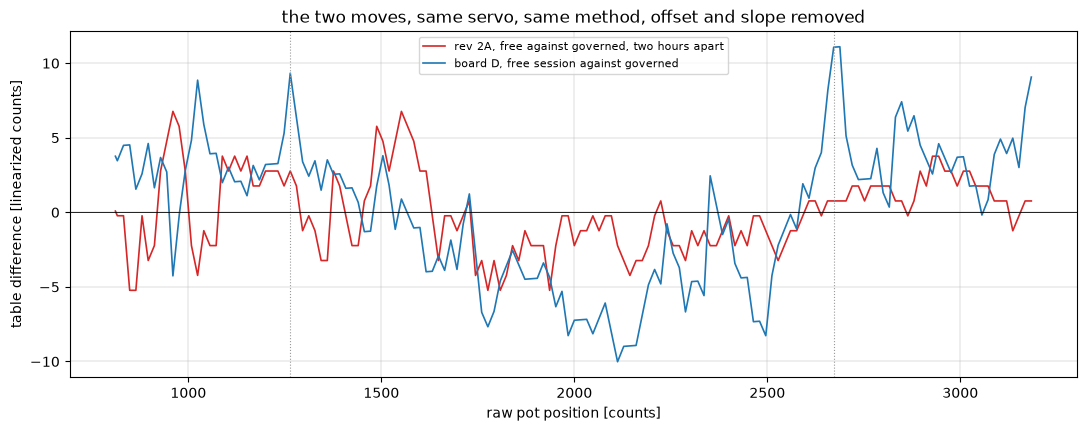

In [6]:
TD = {"D free": table(DF, ALL50), "D governed": table(DG, ALL50)}
d2a = apart(T["2A free"], T["2A governed"])
dd = apart(TD["D free"], TD["D governed"])


def split(d, w=201):
    broad = np.convolve(np.pad(d, w // 2, mode="edge"), np.ones(w) / w, "valid")
    return broad, d - broad


rows = []
for name, d in (("rev 2A, free against governed", d2a), ("board D, free against governed", dd)):
    b, n = split(d)
    near = {f"range near raw {c} [counts]": f"{d[np.abs(X - c) <= 40].min():+.1f} .. {d[np.abs(X - c) <= 40].max():+.1f}"
            for c in (1264, 2672)}
    rows.append({"move": name, "rms": d.std(), "broad rms": b.std(), "narrow rms": n.std(),
                 "largest narrow": n[np.abs(n).argmax()], "at raw": X[np.abs(n).argmax()], **near})
display(pd.DataFrame(rows).set_index("move").round(2))
print(f"the two moves correlate at {np.corrcoef(d2a, dd)[0, 1]:.2f}")
print("rev 2A move every 128 counts:", {int(x): round(float(v), 1) for x, v in zip(X[::128], d2a[::128])})

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(X, d2a, lw=1.2, color="tab:red", label="rev 2A, free against governed, two hours apart")
ax.plot(X, dd, lw=1.2, color="tab:blue", label="board D, free session against governed")
for c in (1264, 2672):
    ax.axvline(c, color="0.6", lw=0.8, ls=":")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("table difference [linearized counts]")
ax.set_title("the two moves, same servo, same method, offset and slope removed")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

**What you are looking at.** One row per move, its rms, the broad and narrow parts, the largest narrow
spot, and what the move does within 40 counts of board D's two narrow spots. The plot draws both moves,
the dotted lines at raw 1264 and 2672.

The rev 2A move is half the size of board D's, 2.52 against 4.58 counts rms over this band. Board D's is
mostly broad, 4.0 broad against 2.0 narrow, and it reaches 9.3 counts near raw 1264 and 11.1 near 2672.
The rev 2A move splits about evenly, 1.7 broad and 1.7 narrow, and moves under 3 counts near either of those.
Its own largest points are at raw 960 and 1552, about 6.5 and 7 counts. Both moves have a narrow spot at
raw 960, of opposite sign. The two moves correlate at 0.42, so they share a little of the broad bow and
little else.

## 5. What the move costs a held-out rung

Notebook 09 section 7's score. Each capture of each session is held out, a table is built from the
other four, and the held-out rungs are scored through it. Then the same rungs through the other
session's whole table, through 0xdc96 (`osc lut build` on the governed session, the table the servo ran
for the free session), and through board D's servo table, 0x14fb. The truth on a rung is its own ripple
angle with an offset and a scale fitted per rung, so what is left is shape. Scored on the settled part
of each rung, from 20 ms after the first tracked sample at the earliest.

In [7]:
M0 = 400
D_SERVO = poslut.GridLut.from_json(json.dumps(SETS["D governed"].pos_lut))


def held_out(test, fn):
    out = []
    for r in test:
        if LO30(r):
            a = max(r["n0"] + M0, r["s0"])
            p, cyc = r["pos"][a:], r["cyc"][a:]
            y = fn(p)
            k, b = np.polyfit(cyc, y, 1)
            out.append((y - (b + k * cyc)).std())
    return np.mean(out)


rows = []
for name, rs, other in (("governed", G, "2A free"), ("free", F, "2A governed")):
    for c in sorted({r["cap"] for r in rs}):
        test = [r for r in rs if r["cap"] == c]
        loo = table([r for r in rs if r["cap"] != c], LO30)
        rows.append({"session": name, "capture": c, "raw": held_out(test, lambda p: p.astype(float)),
                     "own session, capture left out": held_out(test, loo.counts),
                     "the other session": held_out(test, T[other].counts),
                     "0xdc96": held_out(test, T_built["2A governed"].counts),
                     "board D servo table 0x14fb": held_out(test, D_SERVO.counts)})
HO = pd.DataFrame(rows)
print("position error per held-out rung, rms [counts], mean over rungs")
display(HO.groupby("session").mean(numeric_only=True).round(2))
display(HO.set_index(["session", "capture"]).round(2))

position error per held-out rung, rms [counts], mean over rungs


,raw,"own session, capture left out",the other session,0xdc96,board D servo table 0x14fb
session,,,,,
free,9.06,2.29,3.06,3.09,4.56
governed,10.07,2.27,3.20,2.24,5.21


raw  own session, capture left out  the other session  \
session  capture                                                              
governed capture-1  10.26                           2.32               3.29   
         capture-2  10.11                           2.19               3.14   
         capture-3   9.96                           2.29               3.09   
         capture-4  10.04                           2.26               3.23   
         capture-5   9.97                           2.27               3.25   
free     capture-1   8.87                           2.28               3.13   
         capture-2   9.57                           2.19               2.89   
         capture-3   9.25                           2.34               3.04   
         capture-4   8.83                           2.26               3.12   
         capture-5   8.78                           2.36               3.11   

                    0xdc96  board D servo table 0x14fb  
session  capture                                        
governed capture-1    2.29                        5.34  
         capture-2    2.17                        5.19  
         capture-3    2.28                        5.11  
         capture-4    2.22                        5.18  
         capture-5    2.26                        5.23  
free     capture-1    3.15                        4.91  
         capture-2    2.92                        4.59  
         capture-3    3.08                        4.62  
         capture-4    3.15                        4.32  
         capture-5    3.14                        4.34

**What you are looking at.** Position error per held-out rung, rms, through each table. The first
table is the mean per session, the second per capture.

Through a table from its own session a held-out rung reads 2.27 to 2.29 counts, the floor. Through the
other session's table it reads 3.06 to 3.20, so the rev 2A move costs 0.8 to 0.9 counts of position error.
The free captures through 0xdc96, the table the servo was running for them, read 3.09. That is inside
notebook 09's pass line of 1 count over the floor, where board D's move failed it. Board D's servo table
reads 4.56 and 5.21, twice the floor.

## 6. Rev 2A against board D

The same servo on two boards. A pot is ratiometric, so the same pot should read the same counts on any
board up to an offset and a scale, and the tables below take those out. What is left is the pot's
shape as each session saw it, plus whatever the two ADCs do differently code by code.

In [8]:
def registered(ta, tb, shift, scale):
    # tb's shape read at raw counts moved by a shift and a scale about mid travel, against ta's
    xb = (X - 2000) * scale + 2000 + shift
    d = (ta.counts(X) - X) - (tb.counts(xb) - xb)
    return d - np.polyval(np.polyfit(X, d, 1), X)


rows = []
for a in T:
    for b in TD:
        d = apart(T[a], TD[b])
        k = np.abs(d).argmax()
        best = min(registered(T[a], TD[b], s, c).std() for s in range(-80, 81, 4) for c in (0.98, 0.99, 1.0, 1.01, 1.02))
        rows.append({"rev 2A": a, "board D": b, "rms [counts]": d.std(), "largest [counts]": d[k], "at raw": X[k],
                     "best over shift and scale [counts]": best})
rows.append({"rev 2A": "-", "board D": "free against governed", "rms [counts]": dd.std(),
             "largest [counts]": dd[np.abs(dd).argmax()], "at raw": X[np.abs(dd).argmax()]})
pd.DataFrame(rows).set_index(["rev 2A", "board D"]).round(2)

rms [counts]  largest [counts]  at raw  \
rev 2A      board D                                                         
2A governed D free                         6.60            -15.31    2672   
            D governed                     3.48            -14.07     960   
2A free     D free                         5.32            -14.54    2672   
            D governed                     2.55             -7.31     992   
-           free against governed          4.58             11.10    2688   

                                   best over shift and scale [counts]  
rev 2A      board D                                                    
2A governed D free                                               6.39  
            D governed                                           3.34  
2A free     D free                                               5.24  
            D governed                                           2.55  
-           free against governed                                 NaN

**What you are looking at.** Every rev 2A table against every board D table over the rev 2A band, and
board D's own move for scale. The last column is the best a raw shift of up to 80 counts and a scale
of up to 2% on the board D side can do. It barely moves anything, so the two boards read the pot on
the same counts.

The rev 2A tables sit 2.6 to 6.6 counts rms from board D's. The closest pair, the rev 2A free table and
board D's governed one, is as close as the two rev 2A tables are to each other. So whatever the two
ADCs do differently code by code is at most that size, and the rest is the pot moving between
sessions. The farthest pair is the rev 2A governed table against board D's free one, with its largest
point at raw 2672, board D's narrow spot. Board D's free table is the odd one out. Every later table, on
either board, sits closer to board D's governed table than to it.

## 7. What came between the two sessions

From the bench log, in order. Nothing in it is a stall from a seek or an arrival, but two
things load the gears at a stop.

- **`osc lut build` and `osc lut write`** of the governed table, 0xdc96. No drive.
- **`osc ident` run 4**, the table live. Free-shaft bursts and the identification ladder at 26 to 64%
  duty at mid travel, then `ident write --save`.
- **`osc ident verify`.** Current steps of 151 and 215 counts (136 and 194 mA) held at each stop with the
  stall permit, then velocity legs at 600 and 1200 counts per second.
- **The settle-gain bench.** That branch flashed, then a chained ladder at the high stop, 5 to 14% and
  back down (about 0.21 A at the top), run twice, then main 8093e997 flashed back.
- **The free session's pilot and warm-up**, at limit 1100 with seeks and parks at 42%. The pilot's
  jam check found the shaft moving at 40%, so nothing jammed.

Whatever moved the table did it before the first free capture, since the free captures do not drift
(section 3). The held currents at both stops and the stall ladder at the high stop are the events that
load the output against a stop, where board D's stall did. The 42% seeks are the other new thing.
This data cannot pick between them. Sections 8 to 11 run the test that can.

## 8. Three free sessions in a row

The candidates for what moves the table are (a) loading at a stop, (b) running and (c) temperature.
The test that separates them ran on the same servo, board and pack right after the free session above.
It is two more free sessions.

- **free 1** is the free session of sections 1 to 7. With its warm-up it ran from 07:23 to 08:45 UTC.
- **free 2** started at 09:01, 16 minutes after free 1 ended. Nothing ran in between. The servo sat at
  mid travel with the torque off.
- **Between free 2 and free 3**, from 10:05 to 10:06, the output was loaded against the stops and nothing
  else ran. `osc ident verify` at limit 280 held current steps of 135 and 194 mA at each stop under the
  stall permit, then ran its velocity legs at 600 and 1200 counts per second. Then a chained stalled
  ladder at the high stop went from 5 to 14% duty and back down, about 0.21 A at the top (limit 400 in
  RAM). Its park off the stop at 10% aborted as blocked after 88 counts, pos 3836 to 3748.
- **free 3** started at 10:06 and ended at 11:05.

All three run the same procedure under limit 1100, slow decay only, the grid to 50%, seeks and parks at
42%. If the table moves only across the holds, the answer is (a). If it moves across the bare pair as
much, the answer is (b) or (c).

Every session here has its 15 to 50% rungs, so these tables use all of them. Section 2 found the faster
rungs change nothing, and they reach further toward the stops than the 15 to 30% ones.

In [9]:
FREE = {"free 1": SETS["2A free"],
        "free 2": oscnb.datasets.load("mg90-a__dev-v006-2A__2s__limit-1100-b"),
        "free 3": oscnb.datasets.load("mg90-a__dev-v006-2A__2s__limit-1100-c")}
FR = {"free 1": F, **{k: track(d, k, 200.0) for k, d in FREE.items() if k != "free 1"}}
cov = [poslut.well_covered(stitch(rs, ALL50)) for rs in FR.values()]
FB = (max(c[0] for c in cov), min(c[1] for c in cov))
XF = np.arange(FB[0], FB[1] + 1)

rows = []
for k, d in FREE.items():
    ms = [slow_meta(d, c) for c in complete(d)]
    rails = [d.board.rail_from_vbus_counts(m["vbus_counts"]) for m in ms]
    rs = FR[k]
    rows.append({"session": k, "dataset": d.key, "captures": len(ms),
                 "rail [V]": f"{min(rails):.2f} .. {max(rails):.2f}",
                 "rungs 15-50%": sum(15 <= abs(r["duty"]) <= 50 for r in rs), "accepted": sum(ALL50(r) for r in rs),
                 ">= 20 rungs cross": poslut.well_covered(stitch(rs, ALL50))})
display(pd.DataFrame(rows).set_index("session"))
print(f"the session tables below are built from the 15 to 50% rungs and compared over raw {FB[0]} .. {FB[1]}")


,dataset,captures,rail [V],rungs 15-50%,accepted,>= 20 rungs cross
session,,,,,,
free 1,mg90-a__dev-v006-2A__2s__limit-1100,5,7.36 .. 7.41,80,77,"(482, 3603)"
free 2,mg90-a__dev-v006-2A__2s__limit-1100-b,5,7.34 .. 7.35,80,74,"(477, 3644)"
free 3,mg90-a__dev-v006-2A__2s__limit-1100-c,5,7.29 .. 7.32,80,76,"(482, 3619)"


the session tables below are built from the 15 to 50% rungs and compared over raw 482 .. 3603


**What you are looking at.** One row per session. The rail at the start of each capture, the 15 to 50%
rungs the grid holds, how many the tracker accepted, and the stretch at least 20 of them cross.

The rail falls about 0.1 V over the three sessions as the pack drains, which the pot does not see. Every
session tracks 74 to 77 of its 80 rungs, and all three tables are well covered from raw 482 to 3603.

Each session's table against the other two and against its own halves, the same floor as section 2.

In [10]:
FT = {k: table(rs, ALL50, band=FB) for k, rs in FR.items()}


def halves(rs, band, pick=ALL50):
    return apart(table(caps(rs, ODD), pick, band=band), table(caps(rs, EVEN), pick, band=band),
                 np.arange(band[0], band[1] + 1))


d12 = apart(FT["free 2"], FT["free 1"], XF)
d23 = apart(FT["free 3"], FT["free 2"], XF)
H = {k: halves(rs, FB) for k, rs in FR.items()}
pairs = {"free 1 against free 2, nothing between": d12,
         "free 2 against free 3, stop holds and ladder between": d23,
         "free 1 against free 3": apart(FT["free 3"], FT["free 1"], XF),
         **{f"{k}, captures 1, 3, 5 against 2, 4": h for k, h in H.items()}}
display(pd.DataFrame([summary(k, v, XF) for k, v in pairs.items()]).set_index("pair").round(2))


,rms [counts],largest [counts],at raw
pair,,,
"free 1 against free 2, nothing between",0.85,-2.79,3088
"free 2 against free 3, stop holds and ladder between",1.30,-3.46,1472
free 1 against free 3,1.43,-5.38,1360
"free 1, captures 1, 3, 5 against 2, 4",0.56,6.52,482
"free 2, captures 1, 3, 5 against 2, 4",0.55,2.08,482
"free 3, captures 1, 3, 5 against 2, 4",0.67,2.51,482


**What you are looking at.** Each row is two tables and how far apart they sit over raw 482 to 3603,
rms and the largest single point. The last three rows are the split-half floor of each session.

Both steps of the test moved the table. Across the bare pair, with nothing between them, free 1 and free
2 sit 0.85 counts rms apart. Across the stop holds and the ladder, free 2 and free 3 sit 1.30 apart.
The floor is 0.55 to 0.67. So the bare pair moved about 1.5 times the floor and the pair across the
holds about twice. Free 1 and free 3, about two and a half hours apart, sit 1.43 apart.

A half is built from two or three captures, so its noise is a bit higher than a whole session's, and a
gap above it is a real one. The 6.5 count point in free 1's halves sits at raw 482, the band edge, where
the fewest rungs reach.

On their own these numbers do not settle it. The pair across the holds moved more, but the bare pair
moved too, over an hour of running. Section 9 asks whether either move is a step at the boundary or a
drift that runs through the sessions.

## 9. A step at the boundary, or a drift

A table from one capture is noisier than a session's, but there are fifteen of them, in the order they
ran. Every pair gets the same score as before, how far apart the two tables sit with offset and slope
removed, over raw 600 to 3500 where a single capture's rungs reach. If the stop holds moved the table,
the step from the last capture of free 2 to the first of free 3 stands out against the steps inside a
session. If running moves it, the distance grows with time apart and neither boundary is special.

,,rms apart [counts],between them
from,to,,
1.1,1.2,0.82,the cooldown inside a session
1.2,1.3,0.76,the cooldown inside a session
1.3,1.4,0.72,the cooldown inside a session
1.4,1.5,0.90,the cooldown inside a session
1.5,2.1,0.81,"16 min idle, nothing"
2.1,2.2,0.83,the cooldown inside a session
2.2,2.3,0.92,the cooldown inside a session
2.3,2.4,0.80,the cooldown inside a session
2.4,2.5,0.72,the cooldown inside a session


next captures inside a session: median 0.81, range 0.72 .. 1.14
mean rms apart by how many captures apart: {1: 0.82, 2: 0.96, 3: 1.08, 4: 1.22, 5: 1.35, 6: 1.39, 7: 1.48, 8: 1.57, 9: 1.64, 10: 1.63, 11: 1.66, 12: 1.64, 13: 1.6, 14: 1.67}


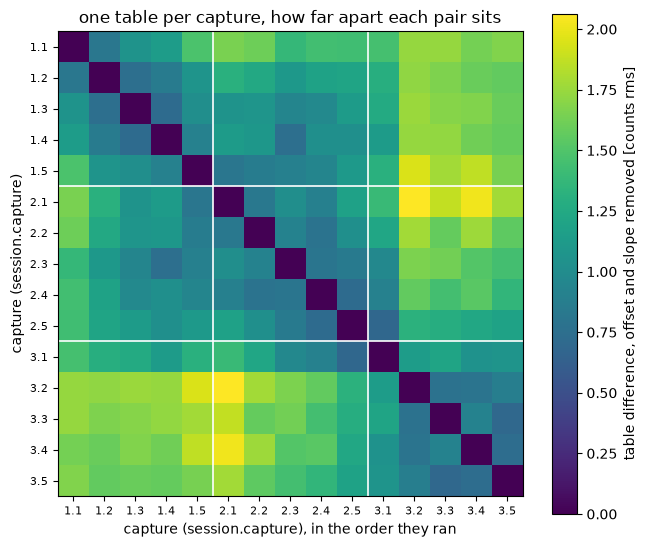

In [11]:
CB = (600, 3500)
XC = np.arange(CB[0], CB[1] + 1)
PC = [(k, c, table([r for r in rs if r["cap"] == c], ALL50, band=CB))
      for k, rs in FR.items() for c in sorted({r["cap"] for r in rs})]
NAMES = [f"{k[-1]}.{c[-1]}" for k, c, _ in PC]
DM = np.array([[apart(a, b, XC).std() if i != j else 0.0 for j, (_, _, b) in enumerate(PC)]
               for i, (_, _, a) in enumerate(PC)])
BETWEEN = {4: "16 min idle, nothing", 9: "stop holds and the stall ladder"}

rows = [{"from": NAMES[i], "to": NAMES[i + 1], "rms apart [counts]": DM[i, i + 1],
         "between them": BETWEEN.get(i, "the cooldown inside a session")} for i in range(len(PC) - 1)]
adj = pd.DataFrame(rows)
display(adj.round(2).set_index(["from", "to"]))
inside = adj[~adj.index.isin(list(BETWEEN))]["rms apart [counts]"]
print(f"next captures inside a session: median {inside.median():.2f}, range {inside.min():.2f} .. {inside.max():.2f}")
print("mean rms apart by how many captures apart:",
      {lag: round(float(np.mean(np.diag(DM, lag))), 2) for lag in range(1, len(PC))})

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(DM, cmap="viridis")
for b in (4.5, 9.5):
    ax.axhline(b, color="w", lw=1.2)
    ax.axvline(b, color="w", lw=1.2)
ax.set_xticks(range(len(PC)), NAMES, fontsize=8)
ax.set_yticks(range(len(PC)), NAMES, fontsize=8)
ax.set_xlabel("capture (session.capture), in the order they ran")
ax.set_ylabel("capture (session.capture)")
ax.set_title("one table per capture, how far apart each pair sits")
fig.colorbar(im, ax=ax, label="table difference, offset and slope removed [counts rms]")
plt.show()


**What you are looking at.** The first table lists each capture against the next one in the order they
ran, and what came between them. The lines under it give the median step inside a session, then the
mean distance between captures 1, 2, up to 14 apart. The map draws every pair, with white lines at the
two session boundaries. Capture 2.3 is free 2's third capture.

Neither boundary stands out. Next captures inside a session sit 0.72 to 1.14 apart, median 0.81.
Across the 16 idle minutes, free 1's last capture and free 2's first sit 0.81 apart. Across the stop
holds and the ladder, free 2's last and free 3's first sit 0.69 apart, the smallest of all fourteen steps.

What grows is the distance with time apart. It is 0.82 for next captures, 1.08 for three apart, 1.35 for
five apart, and it levels off near 1.65 from eight apart on, about an hour and a half. On the map that is the
color brightening away from the diagonal, and it does not change at the white lines.

The largest single step, 1.14, sits inside free 3, between its first and second capture. Three tries
of that second capture were rejected in between (the tool's verdict was that the load changed mid
rung), so the servo drove about 13 minutes more there than between most captures. Free 2 had the same
three rejected tries between its captures 3 and 4 and stepped 0.80 there, so the minutes driven do not
explain that step on their own.

,1.1,1.2,1.3,1.4,1.5,2.1,2.2,2.3,2.4,2.5,3.1,3.2,3.3,3.4,3.5
free 1 to free 3,0.04,0.00,-0.03,-0.01,-0.01,-0.02,0.18,0.16,0.28,0.45,0.60,1.08,1.04,0.99,0.95
free 2 to free 3,0.32,0.19,0.05,0.05,-0.11,-0.25,-0.04,0.06,0.08,0.29,0.49,1.09,1.01,1.05,0.94


,change per capture in run order [counts rms],"orders with a trend as large, of 120",grid slot in the recording,"orders as large, ordered by grid slot"
session,,,,
free 1,0.338,2,"0, 5, 4, 3, 2",120
free 2,0.275,4,"0, 5, 4, 3, 2",116
free 3,0.229,34,"0, 5, 4, 3, 2",44


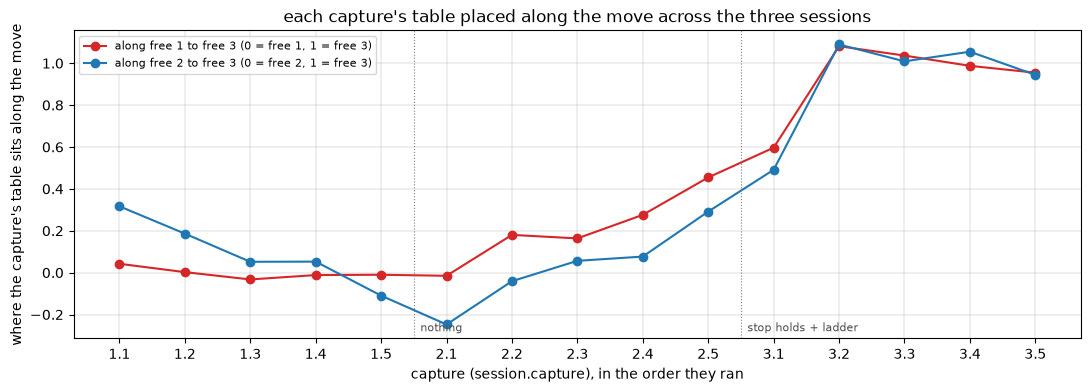

In [12]:
FTC = {k: table(rs, ALL50, band=CB) for k, rs in FR.items()}
moves = {"free 1 to free 3": apart(FTC["free 3"], FTC["free 1"], XC),
         "free 2 to free 3": apart(FTC["free 3"], FTC["free 2"], XC)}
base = {"free 1 to free 3": FTC["free 1"], "free 2 to free 3": FTC["free 2"]}
proj = {m: [float(np.dot(apart(t, base[m], XC), v) / np.dot(v, v)) for _, _, t in PC] for m, v in moves.items()}
display(pd.DataFrame(proj, index=NAMES).T.round(2))

rows = []
for k, rs in FR.items():
    cs = sorted({r["cap"] for r in rs})
    Y = np.array([t.counts(XC) for kk, _, t in PC if kk == k])
    Y = np.array([y - np.polyval(np.polyfit(XC, y, 1), XC) for y in Y - Y.mean(0)])

    def trend(order):
        t = np.asarray(order, float) - np.mean(order)
        return np.sqrt(np.mean((t @ Y / (t @ t)) ** 2))

    slot = [slow_meta(FREE[k], c)["capture"]["order"].index("grid") for c in cs]
    perms = [trend(p) for p in itertools.permutations(range(len(cs)))]
    rows.append({"session": k, "change per capture in run order [counts rms]": trend(range(len(cs))),
                 "orders with a trend as large, of 120": sum(p >= trend(range(len(cs))) - 1e-12 for p in perms),
                 "grid slot in the recording": ", ".join(map(str, slot)),
                 "orders as large, ordered by grid slot": sum(p >= trend(slot) - 1e-12 for p in perms)})
display(pd.DataFrame(rows).set_index("session").round(3))

fig, ax = plt.subplots(figsize=(13, 4))
for m, c in zip(proj, ("tab:red", "tab:blue")):
    ax.plot(range(len(PC)), proj[m], "o-", color=c, label=f"along {m} (0 = {m.split(' to ')[0]}, 1 = free 3)")
for b, what in ((4.5, "nothing"), (9.5, "stop holds + ladder")):
    ax.axvline(b, color="0.5", lw=0.8, ls=":")
    ax.text(b + 0.1, -0.28, what, fontsize=8, color="0.3")
ax.set_xticks(range(len(PC)), NAMES)
ax.set_xlabel("capture (session.capture), in the order they ran")
ax.set_ylabel("where the capture's table sits along the move")
ax.set_title("each capture's table placed along the move across the three sessions")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()


**What you are looking at.** The first table places each capture's table along two moves. On the free 1
to free 3 row, 0 is free 1's whole table and 1 is free 3's. On the free 2 to free 3 row, 0 is free 2's
and 1 is free 3's. The second table tests each session for a trend in run order. It fits every table
point against the capture number and takes the rms of the slopes, then does the same for all 120 orders
of the five captures. A small count means the run order explains the captures better than nearly any
shuffle of them. The block order inside a recording rotates by capture, so the last column orders the
captures by where the grid block sat in the recording instead. The plot draws the first table.

Free 1 and free 2 each drift in run order. Only 2 and 4 of 120 orders give a trend as large, and the
grid slot order explains nothing (120 and 116 of 120). Free 3 has no trend to speak of (34 of 120). It
reaches its own table by its second capture and stays there.

Along free 2 to free 3, free 2 itself goes from -0.25 to 0.29 and free 3's first capture sits at 0.49.
Along free 1 to free 3 the captures read about 0 through free 1, go from about 0 to 0.45 through free 2,
read 0.60 at free 3's first capture and about 1 from its second on. So the move from free 2 to free 3
was under way inside free 2, it carried on across the holds at the same pace, and it finished between
free 3's first and second capture. A step made by the holds would put free 3's first capture at 1.

Free 1 drifts too, but in a direction that does not point at free 3, so it reads about 0 along that move.
The trend test sees it, the plot does not.

## 10. Where it moved, and against the governed move

The two steps of the test, cut into eight stretches of raw position, each against the mean split-half
floor in that stretch. Then both against the governed to free 1 move of section 2, over that section's
band.

,free 1 to 2 rms,free 1 to 2 largest,free 2 to 3 rms,free 2 to 3 largest,"halves rms, mean of three"
raw,,,,,
482 .. 871,0.97,2.45,1.53,2.89,0.86
872 .. 1261,0.74,1.94,1.18,2.80,0.49
1262 .. 1651,0.73,1.97,2.16,3.46,0.48
1652 .. 2042,0.65,1.51,1.54,2.62,0.47
2043 .. 2432,1.00,1.76,0.75,1.92,0.55
2433 .. 2822,0.73,1.93,0.84,1.99,0.56
2823 .. 3212,1.16,2.79,1.06,2.75,0.52
3213 .. 3603,0.67,1.65,0.63,1.69,0.55


over 811 .. 3184: governed to free 1 (section 2) 2.52 counts rms, free 1 to free 2 0.88, free 2 to free 3 1.31, free 1 to free 3 1.47, governed to free 3 2.96
correlation with governed to free 1: free 2 to free 3 0.10, free 1 to free 2 0.11; free 1 to 2 with free 2 to 3 -0.17


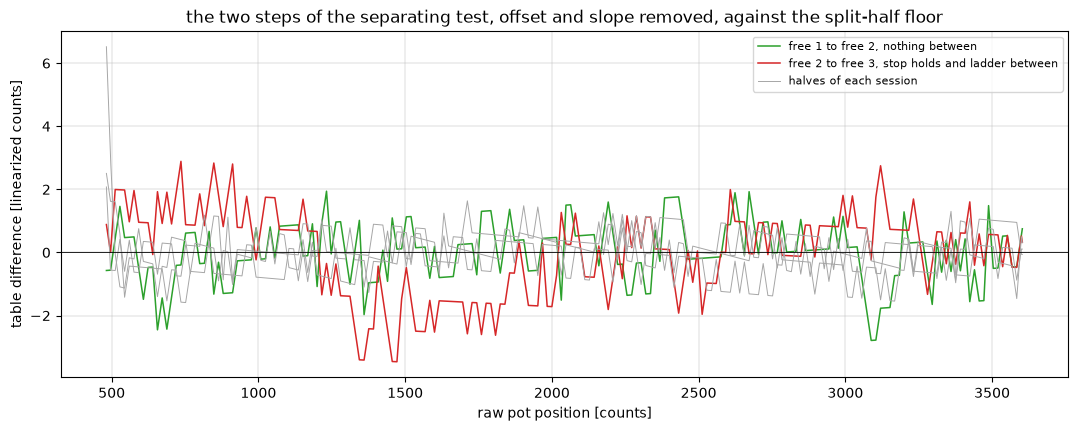

In [13]:
rms = lambda v: np.sqrt(np.mean(v ** 2))
edges = np.linspace(FB[0], FB[1] + 1, 9).astype(int)
rows = []
for a, b in zip(edges[:-1], edges[1:]):
    m = (XF >= a) & (XF < b)
    rows.append({"raw": f"{a} .. {b - 1}",
                 "free 1 to 2 rms": rms(d12[m]), "free 1 to 2 largest": np.abs(d12[m]).max(),
                 "free 2 to 3 rms": rms(d23[m]), "free 2 to 3 largest": np.abs(d23[m]).max(),
                 "halves rms, mean of three": np.mean([rms(h[m]) for h in H.values()])})
display(pd.DataFrame(rows).set_index("raw").round(2))

fx = {k: table(rs, ALL50) for k, rs in FR.items()}
c12 = apart(fx["free 2"], fx["free 1"])
c23 = apart(fx["free 3"], fx["free 2"])
print(f"over {BAND[0]} .. {BAND[1]}: governed to free 1 (section 2) {d2a.std():.2f} counts rms, "
      f"free 1 to free 2 {c12.std():.2f}, free 2 to free 3 {c23.std():.2f}, "
      f"free 1 to free 3 {apart(fx['free 3'], fx['free 1']).std():.2f}, "
      f"governed to free 3 {apart(fx['free 3'], T['2A governed']).std():.2f}")
print(f"correlation with governed to free 1: free 2 to free 3 {np.corrcoef(c23, d2a)[0, 1]:.2f}, "
      f"free 1 to free 2 {np.corrcoef(c12, d2a)[0, 1]:.2f}; free 1 to 2 with free 2 to 3 {np.corrcoef(d12, d23)[0, 1]:.2f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(XF, d12, lw=1.1, color="tab:green", label="free 1 to free 2, nothing between")
ax.plot(XF, d23, lw=1.1, color="tab:red", label="free 2 to free 3, stop holds and ladder between")
for k, h in H.items():
    ax.plot(XF, h, lw=0.7, color="0.65", label="halves of each session" if k == "free 1" else None)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("table difference [linearized counts]")
ax.set_title("the two steps of the separating test, offset and slope removed, against the split-half floor")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()


**What you are looking at.** The table gives each step's rms and largest point per stretch, and the floor.
The lines under it score the moves over raw 811 to 3184, section 2's band, and correlate them. The plot
draws free 1 to free 2 in green, free 2 to free 3 in red and the halves in grey.

Free 1 to free 2 is spread over the whole travel, 0.65 to 1.16 counts rms in every stretch against a
floor of 0.5 to 0.9, its largest point 2.8 counts at raw 3088. Free 2 to free 3 sits in the lower half.
It reads 1.2 to 2.2 from raw 482 to 2042, most from 1262 to 1651 with a dip of about 3.5 counts at raw
1472, and 0.6 to 1.1 above that.

The holds pushed the output into both stops, at about raw 283 and 3830, and the ladder ran at the high
one. The stretch nearest the high stop moved the least of all, 0.63 against a floor of 0.55. The stretch
nearest the low stop, where only the verify holds pushed, moved 1.53, but the largest part of the move
sits further in, around raw 1300 to 1700, nowhere near either stop. The pot right at the stops is
outside the band, so a change there would not show.

Neither step looks like the governed move either. Free 2 to free 3 correlates with governed to free 1
at 0.10, and free 1 to free 2 at 0.11. The two free steps correlate with each other at -0.17, so the
drift does not keep one direction from one hour to the next. It wanders.

Over section 2's band the governed to free 1 move is 2.52 counts rms, and three hours of free running
moved the table 1.47 from free 1 to free 3. Governed to free 3 is 2.96, about what two unrelated moves
of 2.52 and 1.47 add up to (2.92). So the governed to free 1 move is bigger than anything the three
free sessions did, and this test does not explain it.

## 11. Temperature

Nothing on the rig reads the servo's temperature. The pot is ratiometric, so a change that scales its
whole track does not show up in a table at all. Only a change in shape would. The nearest thing on
record is the motor's operating point. Each capture's 30% grid rungs give a settled speed and a settled
current, and a gear train or a winding that warms up moves both.

In [14]:
rows = []
for k, d in FREE.items():
    for c in complete(d):
        df, meta = session.read(d, c, "grid")
        bias = df[df.seg == 0].current_raw.mean()
        row = {"session": k, "capture": c, "rail [V]": d.board.rail_from_vbus_counts(meta["vbus_counts"])}
        for seg, g in df[df.seg > 0].groupby("seg"):
            duty = int(round(g.cmd_duty_q15.iloc[0] * 100 / Q15))
            if abs(duty) == 30:
                st = governed.settled(g, d.board.tick_hz)
                s = "+" if duty > 0 else "-"
                row[f"{s}30% speed [counts/s]"] = abs(ripple.pot_speed(st, d.board.tick_hz, 1.0))
                row[f"{s}30% current [counts]"] = st.current_raw.mean() - bias
        rows.append(row)
display(pd.DataFrame(rows).set_index(["session", "capture"]).round(
    {"rail [V]": 2, "+30% speed [counts/s]": 0, "-30% speed [counts/s]": 0, "+30% current [counts]": 1, "-30% current [counts]": 1}))


rail [V]  +30% speed [counts/s]  +30% current [counts]  \
session capture                                                             
free 1  capture-1      7.41                 4887.0                  117.6   
        capture-2      7.37                 4816.0                  116.2   
        capture-3      7.39                 4777.0                  114.6   
        capture-4      7.36                 4741.0                  115.3   
        capture-5      7.38                 4610.0                  115.3   
free 2  capture-1      7.34                 4543.0                  115.8   
        capture-2      7.35                 4630.0                  115.3   
        capture-3      7.34                 4615.0                  113.8   
        capture-4      7.34                 4579.0                  115.7   
        capture-5      7.34                 4720.0                  116.7   
free 3  capture-1      7.32                 4462.0                  115.8   
        capture-2      7.32                 4534.0                  113.3   
        capture-3      7.29                 4691.0                  116.1   
        capture-4      7.29                 4636.0                  115.1   
        capture-5      7.30                 4743.0                  115.2   

                   -30% speed [counts/s]  -30% current [counts]  
session capture                                                  
free 1  capture-1                 4732.0                  116.5  
        capture-2                 4794.0                  114.9  
        capture-3                 4562.0                  112.6  
        capture-4                 4614.0                  113.3  
        capture-5                 4571.0                  114.0  
free 2  capture-1                 4441.0                  113.7  
        capture-2                 4500.0                  113.4  
        capture-3                 4381.0                  112.7  
        capture-4                 4482.0                  115.2  
        capture-5                 4404.0                  114.7  
free 3  capture-1                 4522.0                  117.4  
        capture-2                 4685.0                  115.3  
        capture-3                 4726.0                  116.4  
        capture-4                 4624.0                  116.7  
        capture-5                 4671.0                  115.7

**What you are looking at.** One row per capture, the rail at its start, and the settled speed and current
of its +30% and -30% rungs.

The current holds at 113 to 118 counts through all three sessions. The speed wanders by a few percent,
and differently in each session. It falls 3 to 6% through free 1, holds within a few percent through free 2
and rises 3 to 6% through free 3. None of that lines up with the table, which drifts through free 1 and free 2 and holds
still through free 3 after its first capture.

So nothing measured here tracks the table, but nothing here is a thermometer either, and (c) stays open.
The one hint is the timing. Three hours back to back on one duty cycle should leave the servo near a
steady temperature after the first session, and the table kept drifting through the second.

## 12. A slipped output gear

The MG90's output gear sits on the pot shaft through a rubber friction bush, not a key. A teardown
after these sessions found it, and found it had moved. A hard enough torque against a stop can turn
the gear on the shaft, and then the pot reads a different raw count for the same output angle. Every
feature of the table locked to the output side, such as the output gear's own run-out against the
motor angle, moves by one constant raw offset, while the shape of the pot's track stays where it
was. That is a candidate for the governed to free step that sections 7 to 10 could not explain, and
for board D's larger one, which straddled a stall that moved the low stop.

The test needs no new data. Read one table at raw counts shifted by a constant and see how close the
other lands, against the split-half floor of the two sessions. A slip of a table whose shape is locked
to the output predicts one shift that brings the difference down to the floor. A move in the pot's
own shape predicts that no shift does much better than none. A residual between the two is not a
verdict, because a table can carry both kinds of feature and a slip only moves one of them. The
free-session steps are the control, since nothing loaded a stop between free 1 and free 2.

,"rms, no shift (offset and slope removed)",best shift [raw counts],rms at the best shift,split-half floor,best over floor
pair,,,,,
"rev 2A, governed against free 1 (the open step)",2.52,-1,2.51,0.62,4.04
"board D, governed against free",4.55,3,4.52,0.49,9.31
"rev 2A, free 1 against free 2 (nothing between)",0.86,0,0.86,0.59,1.45
"rev 2A, free 2 against free 3 (stop holds between)",1.31,-1,1.29,0.59,2.17


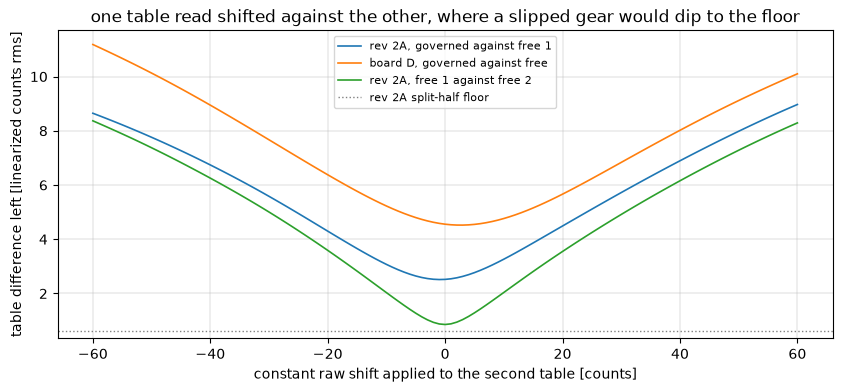

In [15]:
SHIFTS = np.arange(-60, 61)          # raw counts; a slip of a few degrees at the output is tens of counts


def inner(x, edge=60):
    # Keep the shifted read inside the band both tables were fitted over.
    return x[(x >= x[0] + edge) & (x <= x[-1] - edge)]


def shifted(ta, tb, shift, x):
    # tb's shape read at raw counts moved by a constant, against ta's, offset and slope removed
    d = (ta.counts(x) - x) - (tb.counts(x + shift) - (x + shift))
    return d - np.polyval(np.polyfit(x, d, 1), x)


def slip_test(name, ta, tb, x, floor):
    x = inner(x)
    r = np.array([shifted(ta, tb, s, x).std() for s in SHIFTS])
    k = int(np.argmin(r))
    return {"pair": name, "rms, no shift (offset and slope removed)": r[SHIFTS == 0][0], "best shift [raw counts]": int(SHIFTS[k]),
            "rms at the best shift": r[k], "split-half floor": floor,
            "best over floor": r[k] / floor}


floor_2a = np.mean([gaps["governed, captures 1, 3, 5 against 2, 4"].std(), gaps["free, captures 1, 3, 5 against 2, 4"].std()])
floor_free = np.mean([h.std() for h in H.values()])
try:
    floor_d = np.mean([halves(rs, BAND).std() for rs in (DF, DG)])
except AssertionError:
    floor_d = np.nan                 # a half of a board D session does not cover the band
SLIP = pd.DataFrame([
    slip_test("rev 2A, governed against free 1 (the open step)", T["2A free"], T["2A governed"], X, floor_2a),
    slip_test("board D, governed against free", TD["D governed"], TD["D free"], X, floor_d),
    slip_test("rev 2A, free 1 against free 2 (nothing between)", FT["free 2"], FT["free 1"], XF, floor_free),
    slip_test("rev 2A, free 2 against free 3 (stop holds between)", FT["free 3"], FT["free 2"], XF, floor_free),
]).set_index("pair")
display(SLIP.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for name, (ta, tb, x) in {"rev 2A, governed against free 1": (T["2A free"], T["2A governed"], X),
                          "board D, governed against free": (TD["D governed"], TD["D free"], X),
                          "rev 2A, free 1 against free 2": (FT["free 2"], FT["free 1"], XF)}.items():
    xi = inner(x)
    ax.plot(SHIFTS, [shifted(ta, tb, s, xi).std() for s in SHIFTS], lw=1.2, label=name)
ax.axhline(floor_2a, color="0.5", ls=":", lw=1, label="rev 2A split-half floor")
ax.set_xlabel("constant raw shift applied to the second table [counts]")
ax.set_ylabel("table difference left [linearized counts rms]")
ax.set_title("one table read shifted against the other, where a slipped gear would dip to the floor")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

**What you are looking at.** One row per pair of tables, with how far apart they sit with offset and
slope removed, the constant raw shift of the second table that brings them closest, what is left at
that shift, and the split-half floor of the sessions involved. The plot is the rms left against the
shift for three of the pairs.

**No constant shift closes the step.** The governed to free 1 step is 2.52 counts rms with no shift
and 2.51 at its best shift, -1 raw count, four times the 0.62 floor. Board D's step is 4.55, and 4.52
at +3 counts, nine times its floor. Neither curve dips. A whole table moved by a constant raw offset
is not what either step looks like, and with offset and slope already removed it is not a constant
in linearized counts either. The free-session controls behave the same way, with the best shift at
0 or -1.

So on these tables the data does not confirm a slip, and it does not rule one out. If the table's
shape is mostly the pot track's own, a slip moves only the smaller output-side part and leaves the
rest in place, and this test cannot see it. What separates a slip from a change in the pot is an
output angle reference that does not go through the pot, the camera route of notebook 13 or an
encoder on the output, read before and after a stall at a stop. A slip moves the pot against that
reference by one constant angle, and a change in the pot's own shape does not.

## What this says

**The current limit did not move the table.** Two hours apart, on the same pack, with no seek or
arrival stalling in between, the free and governed tables still differ by 2.5 counts rms, four times
the split-half floor of 0.6. The difference stays at 2.45 with every rung's climb cut out, where both
rules drive the motor the same way. Within each session neither the duty nor the climb moves the table.

**Loading at a stop did not move it either, at these loads.** Holding 135 and 194 mA at both stops and a
stalled ladder to about 0.21 A at the high stop moved the table less than one capture to the next does
inside a session (0.69 counts rms against 0.72 to 1.14). The stretch next to the high stop, where the
ladder ran, moved the least.

**Running moves it, slowly.** Through three hours of free sessions the table drifts at about the pace
the captures run, inside the sessions and across both boundaries alike. Captures an hour and a half or
more apart sit about 1.65 counts rms apart, and session tables one to three hours apart 0.85 to 1.43. The drift
wanders rather than holding one direction. Temperature was not measured, so it cannot be ruled out as
what drives it, but nothing that was measured tracks it.

**The governed to free move is still open.** It came as one step between the two sessions, followed the
output's position and not its direction, and at 2.5 counts rms it is bigger than three hours of free
running produced. Board D's move behaved the same way at about twice the size, so board D's 4.4 counts was most likely
the same kind of move, and the limit was not behind it either. A slipped output gear is a candidate
for both, since the gear sits on a friction bush, but neither step is one table shifted by a constant
raw offset (section 12), so the candidate is not confirmed.

**For the table policy nothing changes.** A table goes stale between sessions by 1 to 5 counts rms of
shape. A user calibrates again from time to time and after a hard stall, and a notebook scores the pot
through a table built from the dataset it reads. Here the stale table cost 0.8 counts of held
out position error, inside notebook 09's pass line.

## Caveats

- **One servo, one night.** Four sessions on one board over about five hours. Whether the drift keeps
  going over days or stays inside the 1.65 counts it reached here needs sessions on other days.
- **15 to 30% only, for the governed comparison.** The governed grid stops at 30% on this pack, so
  sections 1 to 7 use the same duties on both sides. In the free session, tables from the 15 to 25% and
  the 35 to 50% rungs agree to 0.90 counts rms, so the faster rungs would not change the answer. Sections
  8 to 11 compare free sessions only and use their 15 to 50% rungs.
- **The band.** Sections 2, 4 and 5 run over raw 811 to 3184, where at least 20 rungs of the free 15 to
  30% table cross. The direction and per capture cuts of section 3 run over 1330 to 2690, the settled cut
  over the stretch at least 10 settled rungs of each session cross. The free sessions compare over 482 to
  3603, their per capture tables over 600 to 3500. The stops, at about raw 283 and 3830, and the pot
  right next to them are outside every comparison.
- **The loads at the stops are the ones tried.** Current steps of 135 and 194 mA and a ladder to about
  0.21 A. Board D's stall was a harder load, the one that moved its low stop, and nothing that hard ran
  here.
- **One capture's table is noisy.** About 16 rungs each, 0.7 to 1.1 counts rms from the next capture.
  Section 9's reading rests on the pattern over fifteen of them, not on any single step.
- **No thermometer.** Section 11's speed and current are a motor operating point, not a temperature.
- **Board D used a different tracker floor.** 250 Hz there, 200 here, both as their own notebooks run
  them. It only moves where a rung's first tracked sample lands.
- **The events between sessions come from the bench log**, not from recordings in a dataset, and so do
  the session times in section 8. The currents are what the tools printed.

## Open

- **What moves the pot between sessions.** The candidates were (a) loading at a stop, (b) running and
  (c) temperature, and sections 8 to 11 ran the separating test. Verdict, (a) is ruled out at the loads
  tried. Across the stop holds and the stall ladder the table stepped 0.69 counts rms, the smallest of
  fourteen capture to capture steps (0.72 to 1.14 inside the sessions), the move was already under way
  before them, and the stretch next to the high stop moved the least. The move sits in the lower half
  of travel, most around raw 1300 to 1700. The table drifts with running
  time instead, 0.81 across a bare 16 minute pause, growing to about 1.65 between captures an hour and
  a half or more apart, and both free 1 and free 2 trend in run order (2 and 4 of 120 orders). That fits (b).
  (c) is not separated, because nothing reads the temperature. What separates (b) from (c) is a free
  session started cold after the servo sits overnight, compared with free 3. If running moves the table,
  the cold session's first capture sits about one capture step (0.7 to 0.8) from free 3's table and the
  drift carries on at the same pace. If temperature moves it, the first capture sits further off and the
  next few move fast while the servo warms, then settle.
- **What moved the table between the governed session and free 1.** 2.5 counts rms in about 80 minutes,
  where three hours of free running moved it 1.5, and its shape matches neither free step (correlation
  0.10 and 0.11). Besides the stop holds and the ladder this test repeated, that gap held `osc ident`
  run 4 (free-shaft bursts and an identification ladder at 26 to 64% duty at mid travel), the ladder a
  second time, two flashes, and the free pilot and warm-up, the first runs of the evening with seeks at
  42% and grid rungs to 50%. The high-duty
  ident ladder is the biggest load on the gears in that list. What separates it is a free session, then
  `osc ident` alone, then another free session. If the table steps across the ident run by more than a capture step, the high-duty driving moved it.
  A slip of the output gear on its friction bush is the other candidate (section 12). A constant raw
  shift does not reproduce the step, which leaves it unconfirmed rather than excluded, and an output
  angle reference that does not go through the pot, read across a stall at a stop, separates it from
  a change in the pot's own shape.